In [1]:
import parcels
import math
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import scipy

import trajan
import cartopy.crs as ccrs
import cartopy.feature
from datetime import datetime, timedelta
import calculate_distance as c_d
import calculate_2DHistogram_method01 as c_H
import matplotlib.colors as mcolors
import cmocean.cm as cmo
from matplotlib import colormaps as mcolormaps

In [2]:
directory_phy =  '/storage/shared/oceanparcels/input_data/MOi/'

U_base_file =  directory_phy + 'GLO12/psy4v3r1-daily_U_2024-01-01.nc'
V_base_file =  directory_phy + 'GLO12/psy4v3r1-daily_V_2024-01-01.nc'
S_base_file =  directory_phy + 'GLO12/psy4v3r1-daily_S_2024-01-01.nc'

ds = xr.open_dataset(S_base_file)
ds


<xarray.Dataset> Size: 5GB
Dimensions:       (deptht: 50, y: 3059, x: 4322)
Coordinates:
  * deptht        (deptht) float32 200B 0.494 1.541 ... 5.275e+03 5.728e+03
    nav_lat       (y, x) float32 53MB ...
    nav_lon       (y, x) float32 53MB ...
    time_counter  datetime64[ns] 8B ...
  * x             (x) int32 17kB 1 2 3 4 5 6 7 ... 4317 4318 4319 4320 4321 4322
  * y             (y) int32 12kB 1 2 3 4 5 6 7 ... 3054 3055 3056 3057 3058 3059
Data variables:
    vosaline      (deptht, y, x) float64 5GB ...
Attributes:
    Conventions:  CF-1.0
    file_name:    ORCA12_LIM-T00_y2025m02d24_gridS.nc
    institution:  MERCATOR OCEAN
    source:       NEMO
    TimeStamp:    2025-MAR-02 18:30:45 GMT-0000
    references:   http://www.mercator-ocean.eu
    history:      Mon Mar 10 13:52:57 2025: ncrcat -O upper_S_z.nc lower_S_z....
    NCO:          netCDF Operators version 5.3.1 (Homepage = http://nco.sf.ne...

In [3]:
def create_grid_mask(zonal_velocity_file: str, lonmin: float, latmin: float, 
                     lonmax: float, latmax: float, depth: float, 
                     direction: str, outputfile: str) -> xr.DataArray:
    
    lon_name = 'nav_lon'  #default longitude coordinate in NEMO datasets
    lat_name = 'nav_lat'  #default latitude coordinate in NEMO datasets
     
    ds = xr.open_dataset(zonal_velocity_file) #Opening the NetCDF dataset containing zonal velocity data
    
    #Selecting the velocity component at the nearest depth level to 'depth'
    dv = ds['vozocrtx'].sel(deptht=depth, method='nearest') #'vozocrtx' is the zonal (x-direction) velocity
    
    #Printing shape of the coordinate arrays
    print(ds['nav_lon'].shape, ds['nav_lat'].shape)

    #Extracting the longitude and latitude arrays
    longrid = ds[lon_name]
    latgrid = ds[lat_name]

    #Create an array full of ones, same shape as the longitude/latitude grid
    #This will serve as the initial mask (all points "valid")
    mask = xr.DataArray(
        np.ones_like(longrid),  # fill array with ones
        dims=longrid.dims,      # use same dimensions as longrid (e.g., lat, lon)
        coords={lon_name: longrid, lat_name: latgrid}  # attach coordinates
    )

    # Modify the mask based on missing velocity values depending on 'direction'
    if direction == 'up':
        # For 'up', keep points where velocity is missing (NaN), set others to NaN
        mask = mask.where(dv.isnull(), np.nan)
    elif direction == 'down':
        # For 'down', keep points where velocity exists, set missing points to NaN
        mask = mask.where(~dv.isnull(), np.nan)
    else:
        # If direction is not recognized, raise an error
        raise ValueError(f'{direction} should be up or down!')

    #Also selecting specific longitude/latitude domain and setting points outside bounds to NaN
    mask = mask.where(
        (longrid >= lonmin) & (longrid <= lonmax) &  #longitude within domain
        (latgrid >= latmin) & (latgrid <= latmax),   #latitude within domain
        np.nan  )

    #If an output file path is given, saving the mask as NetCDF file
    if outputfile:
        mask.to_netcdf(outputfile)
        print(f"Landmask is saved as: {outputfile}")

    #Returning the final mask DataArray
    return mask


In [54]:
MASK = create_grid_mask(
    #zonal_velocity_file = '/storage/shared/oceanparcels/input_data/MOi/GLO12/psy4v3r1-daily_U_2024-07-01.nc',
    zonal_velocity_file = U_base_file,
    lonmin = -100,
    latmin = -10,
    lonmax = -10,
    latmax = 30,
    depth = 5,
    direction = 'up',
    outputfile = '/storage/shared/oceanparcels/output_data/data_Elena/LANDMASK_small_depth.nc'
)

(3059, 4322) (3059, 4322)
Landmask is saved as: /storage/shared/oceanparcels/output_data/data_Elena/LANDMASK_small_depth.nc


In [46]:
def grid_creation(lon_min, lon_max, lat_min, lat_max, landmask: xr.DataArray,
                      nlon=12, nlat=12, lon_name='lon', lat_name='lat'):
    """
    Creating a regular grid of lon/lat points for a fieldset with resolution of 1/12 deg.
    Removing points where landmask == 1.
    """
    #Creating evenly spaced coordinates between minimum and maximum lon and lat and nlon/nlat particles per degree
    release_lon = np.linspace(lon_min, lon_max, ((lon_max-lon_min)*nlon + 1))
    release_lat = np.linspace(lat_min, lat_max, ((lat_max-lat_min)*nlat + 1))

    #Creating meshgrid and flatten
    lon_grid, lat_grid = np.meshgrid(release_lon, release_lat)
    
    #Converting to 1D arrays for vectorized sampling
    lon_flat = lon_grid.ravel()
    lat_flat = lat_grid.ravel()

    #Extracting the nav_lon/nav_lat arrays
    nav_lon = landmask['nav_lon'].values
    nav_lat = landmask['nav_lat'].values

    #Using scipy’s griddata as interpolater for 2D coordinate fields
    from scipy.interpolate import griddata

    #Combining the 2D longitude and latitude grids into a single array of coordinate pairs (lon, lat)
    points = np.column_stack((nav_lon.ravel(), nav_lat.ravel()))

    #Flattening the landmask array to match the flattened coordinate pairs
    landmask_values = landmask.values.ravel()

    #Interpolating the landmask data onto the target grid defined by (lon_flat, lat_flat)
    landmask_interp = griddata(points, landmask_values, (lon_flat, lat_flat), method='nearest')

    #Creating a mask that only selects suitable points in the ocean () and apply it on lon and lat dataset to create a grid in the ocean
    grid_mask = (landmask_interp != 1)     #!= 1 (means is not 1 aka not land)
    lon_grid = lon_flat[grid_mask]
    lat_grid = lat_flat[grid_mask]

    return lon_grid, lat_grid

In [7]:
GRIDMASKcheck = xr.open_dataarray('/storage/shared/oceanparcels/output_data/data_Elena/LANDMASK_CHECK.nc') 
# Rename coordinates for compatibility
GRIDMASKcheck = GRIDMASKcheck.rename({'x': 'lon', 'y': 'lat'})

grid_lon, grid_lat = grid_creation(
    lon_min=-57, lon_max=-21,
    lat_min=-1, lat_max=16,
    nlon=12, nlat=12,
    landmask=GRIDMASKcheck
)

GRIDMASK200 = xr.open_dataarray('/storage/shared/oceanparcels/output_data/data_Elena/LANDMASK_with_depth_200.nc') 
# Rename coordinates for compatibility
GRIDMASK200 = GRIDMASK200.rename({'x': 'lon', 'y': 'lat'})

grid_lon, grid_lat = grid_creation(
    lon_min=-57, lon_max=-21,
    lat_min=-1, lat_max=16,
    nlon=12, nlat=12,
    landmask=GRIDMASK200
)


In [52]:
print(np.shape(grid_lon))
print(len(grid_lon.tolist()))

nparticles = len(grid_lon.tolist())
print(nparticles)

print(type(nparticles))

(78205,)
78205
78205
<class 'int'>


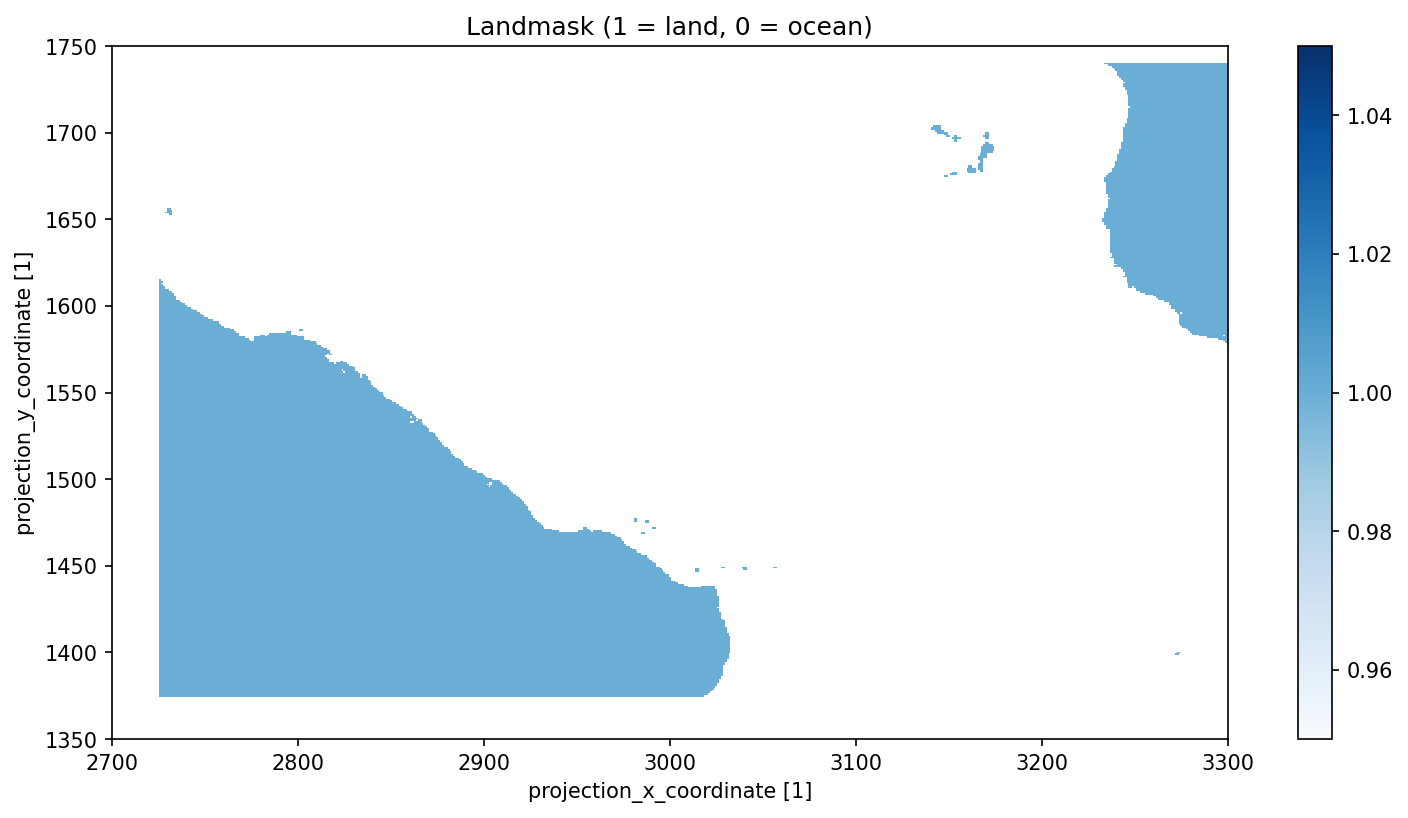

In [39]:
plt.figure(figsize=(12,6), dpi = 150)
GRIDMASK200.plot(cmap='Blues')
plt.title("Landmask (1 = land, 0 = ocean)")
plt.xlim(2700,3300)
plt.ylim(1350, 1750)
plt.show()

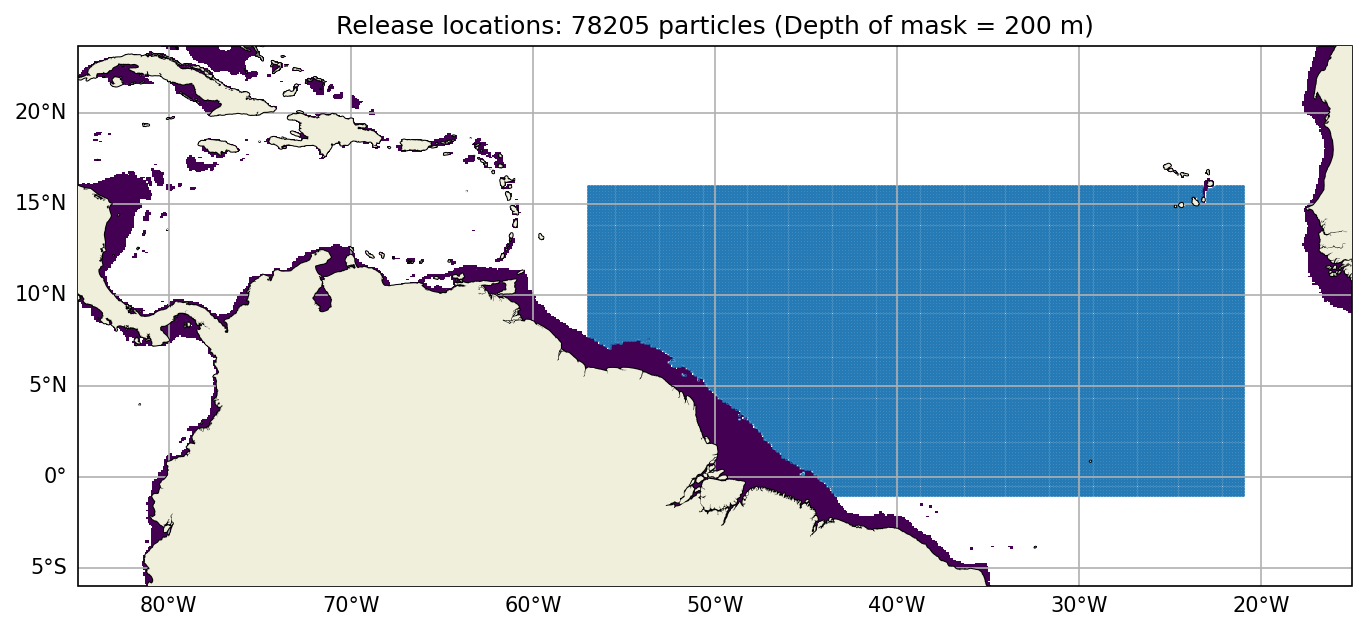

In [41]:
fig = plt.figure(figsize = (9,5), constrained_layout=True, dpi=150)
ax = plt.axes(projection=ccrs.PlateCarree())
p = ax.pcolormesh(
    GRIDMASKcheck['nav_lon'], GRIDMASKcheck['nav_lat'], GRIDMASKcheck,
    cmap='viridis', transform=ccrs.PlateCarree(), zorder = 1, label='Landmask'
)
ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'),zorder=3)
ax.add_feature(cartopy.feature.LAND.with_scale('10m'), zorder=4)
ax.gridlines(draw_labels=['left','bottom'], zorder=0)
ax.set_extent([-85,-15,-5,20])
#ax.set_extent([-58,-18,-3,17])
ax.set_title(f'Release locations: {len(grid_lon.tolist())} particles (Depth of mask = 200 m)')

ax.scatter(grid_lon, grid_lat, s = 0.1, label='Release points')
#plt.legend()

plt.show()

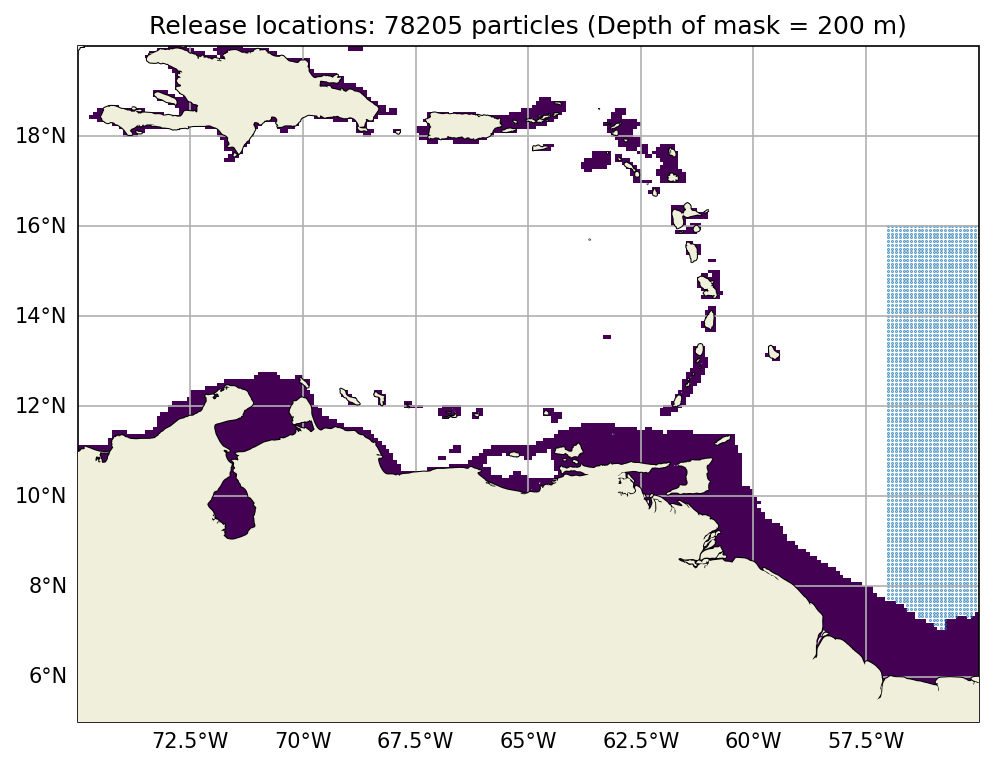

In [ ]:
fig = plt.figure(figsize = (9,5), constrained_layout=True, dpi=150)
ax = plt.axes(projection=ccrs.PlateCarree())
p = ax.pcolormesh(
    GRIDMASK200['nav_lon'], GRIDMASK200['nav_lat'], GRIDMASK200,
    cmap='viridis', transform=ccrs.PlateCarree(), zorder = 1
)
ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'),zorder=3)
ax.add_feature(cartopy.feature.LAND.with_scale('10m'), zorder=4)
ax.gridlines(draw_labels=['left','bottom'], zorder=0)
ax.set_extent([-85,-15,-5,20])
#ax.set_extent([-58,-18,-3,17])
ax.set_extent([-75, -55, 5, 20])
#ax.set_extent([-56,-40,4,15])
ax.set_title(f'Release locations: {len(grid_lon.tolist())} particles (Depth of mask = 200 m)')

ax.scatter(grid_lon, grid_lat, s = 0.1)

plt.show()

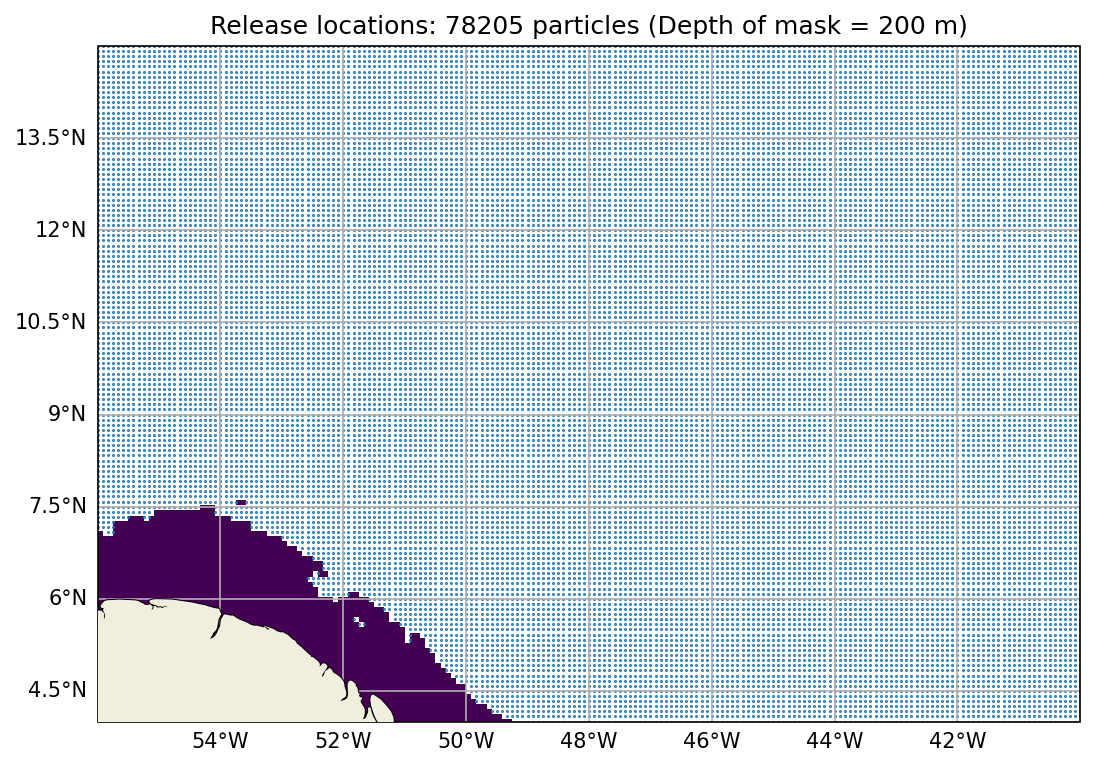

In [ ]:
fig = plt.figure(figsize = (9,5), constrained_layout=True, dpi=150)
ax = plt.axes(projection=ccrs.PlateCarree())
p = ax.pcolormesh(
    GRIDMASK200['nav_lon'], GRIDMASK200['nav_lat'], GRIDMASK200,
    cmap='viridis', transform=ccrs.PlateCarree(), zorder = 1
)
ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'),zorder=3)
ax.add_feature(cartopy.feature.LAND.with_scale('10m'), zorder=4)
ax.gridlines(draw_labels=['left','bottom'], zorder=0)
#ax.set_extent([-85,-15,-5,20])
#ax.set_extent([-58,-18,-3,17])
#ax.set_extent([-75, -55, 5, 20])
ax.set_extent([-56,-40,4,15])
ax.set_title(f'Release locations: {len(grid_lon.tolist())} particles (Depth of mask = 200 m)')

ax.scatter(grid_lon, grid_lat, s = 0.2)

plt.show()

Shape of coordinate grids: (2420, 2915) (2420, 2915) and length of lon array: 2915
Horizontal resolution =  0.00909090909090909 deg. So meaning  1.009090909090909 km
Amount of particles that will be released: 803750 42525 vs  6655000 so 0.6389932381667919 % coverage
Sargassum release locations array:  Frozen({'dim_0': 2420, 'dim_1': 2915})


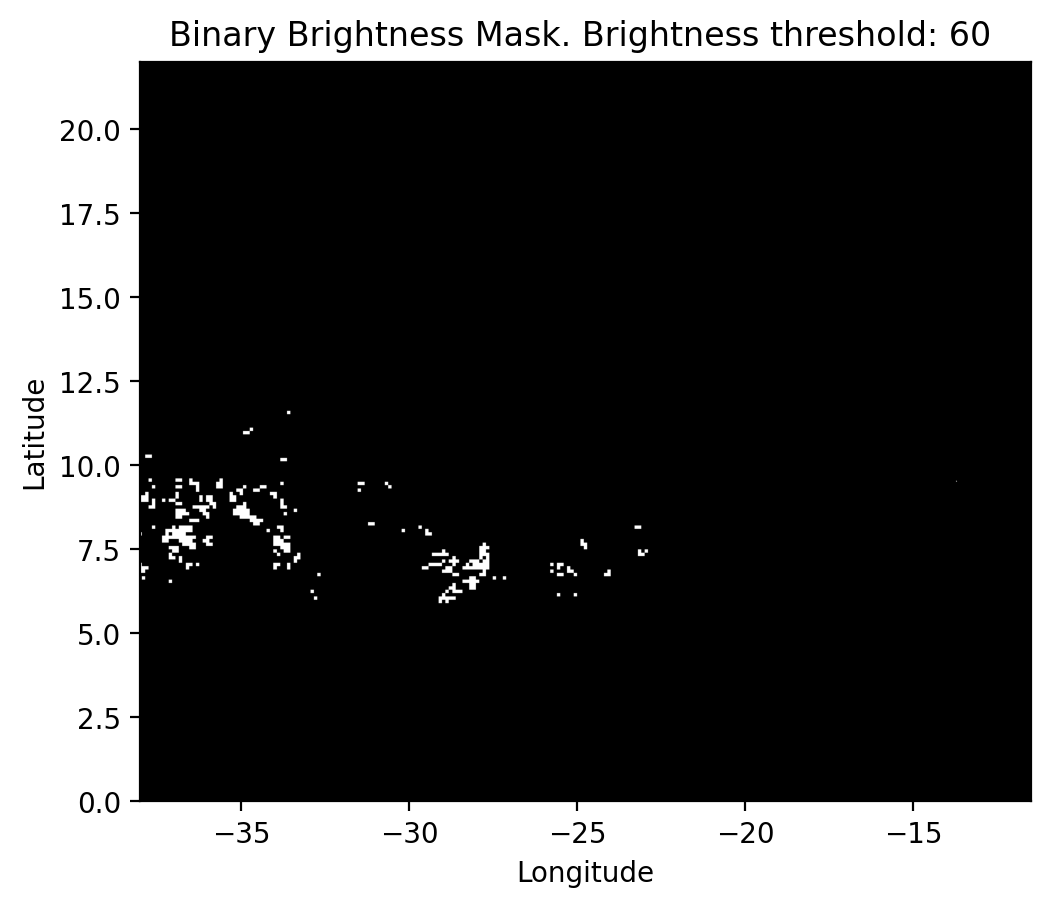

In [3]:
from PIL import Image

#Loading the image
image_name = "/nethome/6903894/testing/Input_data_test/C20241772024183.1KM.CE_ATLANTIC.7DAY.L3D.FA_UNET_DENSITY.png"
img = Image.open(image_name).convert("RGB")
img_array = np.array(img)

#Computing brightness by approximating average or weighted sum of RGB
brightness = img_array.mean(axis=2)

#Creating a land mask based on the brown color of landmass
r, g, b = img_array[:,:,0], img_array[:,:,1], img_array[:,:,2]
#land_mask = (r > 80) & (g > 40) & (g < 120) & (b < 80)
#Brown tends to be dark, reddish, and not too saturated
land_mask = (
    (r > 60) & (r < 160) &          # moderate red
    (g > 30) & (g < 110) &          # moderate green
    (b < 70) &                      # low blue
    (brightness < 120) &            # exclude bright oranges
    ((r - g) > 15) &                # red clearly higher than green
    ((r - b) > 40)                  # red much higher than blue
    )
#Expanding land mask with binary_dilation method by ~10 pixels (~10 km at 1 km resolution)
from scipy.ndimage import binary_dilation
expanded_land_mask = binary_dilation(land_mask, iterations=10)

#Setting threshold to get binary mask - threshold can be adjusted depending on image (try 80–150 range)
threshold = 60
binary_mask = (brightness > threshold).astype(int)
sum_binary_mask = np.sum(binary_mask)
#Applying the expaned land mask on binary mask
binary_mask[expanded_land_mask] = 0
sum2_binary_mask = np.sum(binary_mask)

#Creating coordinate grids based on bounding boxes
#north, south, east, west = 22.0, 0.0, -38.0, -63.0
north, south, east, west =22.0, 0.0, -11.5, -38.0
height, width = binary_mask.shape

lats = np.linspace(north, south, height)
lons = np.linspace(west, east, width)

#Creating 2D coordinate grids
lon_grid, lat_grid = np.meshgrid(lons, lats)

#Creating 2d grids of Sargassum release locations
xr_lon_grid = xr.DataArray(lon_grid)
xr_lat_grid = xr.DataArray(lat_grid)
sarg_lon_grid = xr_lon_grid.where(binary_mask == 1)
sarg_lat_grid = xr_lat_grid.where(binary_mask == 1)

#Checking output:
hor_resolution = (east-west)/len(lons)
print('Shape of coordinate grids:', np.shape(lon_grid), np.shape(binary_mask), 'and length of lon array:', len(lons))
print('Horizontal resolution = ', hor_resolution, 'deg. So meaning ', hor_resolution*111 , 'km' )
print(f'Amount of particles that will be released:', sum_binary_mask, sum2_binary_mask, 'vs ', 2420*2750, 'so', 100*sum2_binary_mask/(2420*2750), '% coverage')
print('Sargassum release locations array: ', sarg_lon_grid.sizes)
#Plotting results
fig = plt.figure(dpi=200)
plt.imshow(binary_mask, extent=[west, east, south, north], cmap='grey' )
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"Binary Brightness Mask. Brightness threshold: {threshold} ")
plt.show()

In [4]:
#Making a coarser mask and release grid by only selecting every second element
coarse_mask = binary_mask[::2, ::2]
coarse_lat_grid = lat_grid[::2, ::2]
coarse_lon_grid = lon_grid[::2, ::2]

coarse_xr_lon_grid = xr.DataArray(coarse_lon_grid)
coarse_xr_lat_grid = xr.DataArray(coarse_lat_grid)
coarse_sarg_lon_grid = coarse_xr_lon_grid.where(coarse_mask == 1)
coarse_sarg_lat_grid = coarse_xr_lat_grid.where(coarse_mask == 1)

print(np.shape(coarse_lon_grid), np.shape(coarse_sarg_lon_grid))

(1210, 1458) (1210, 1458)


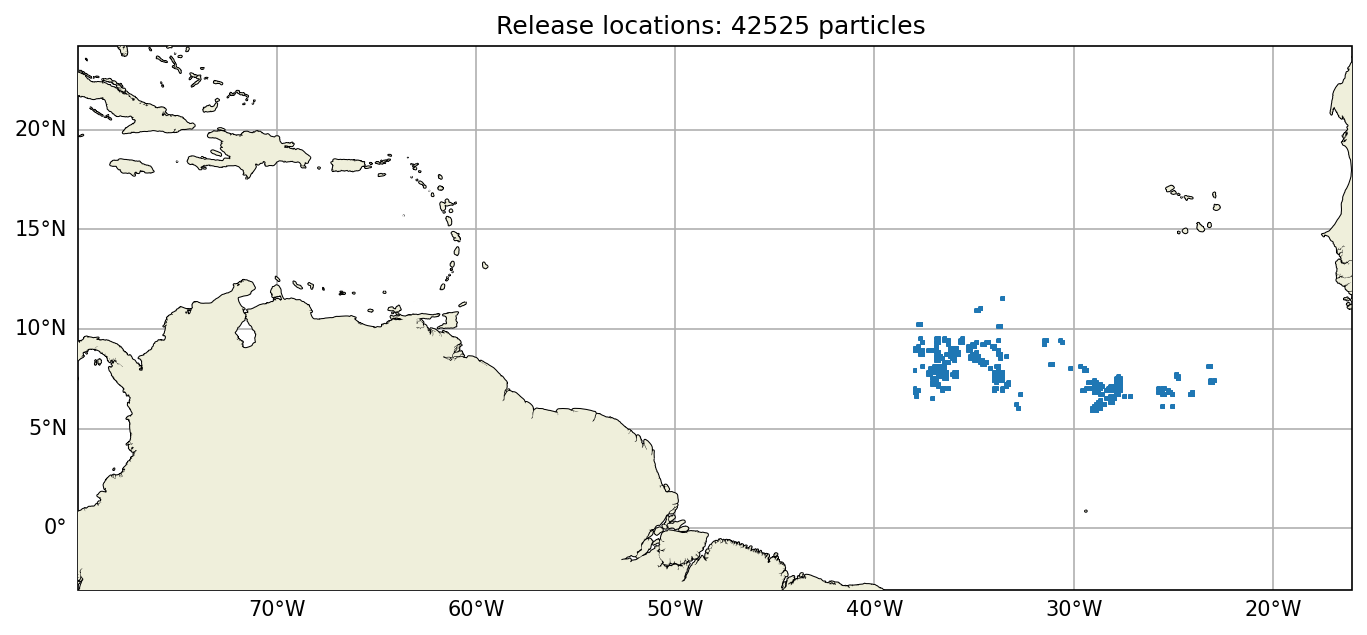

In [5]:
fig = plt.figure(figsize = (9,5), constrained_layout=True, dpi=150)
ax = plt.axes(projection=ccrs.PlateCarree())
# p = ax.pcolormesh(
#     GRIDMASKcheck['nav_lon'], GRIDMASKcheck['nav_lat'], GRIDMASKcheck,
#     cmap='viridis', transform=ccrs.PlateCarree(), zorder = 1, label='Landmask'
# )
ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'),zorder=3)
ax.add_feature(cartopy.feature.LAND.with_scale('10m'), zorder=4)
ax.gridlines(draw_labels=['left','bottom'], zorder=0)
ax.set_extent([-85,-15,-5,20])
ax.set_extent([-80,-16, -3,21])
ax.set_title(f'Release locations: {sum2_binary_mask} particles ')

ax.scatter(sarg_lon_grid, sarg_lat_grid, s = 0.1, label='Release points',zorder=5)
#plt.legend()

plt.show()

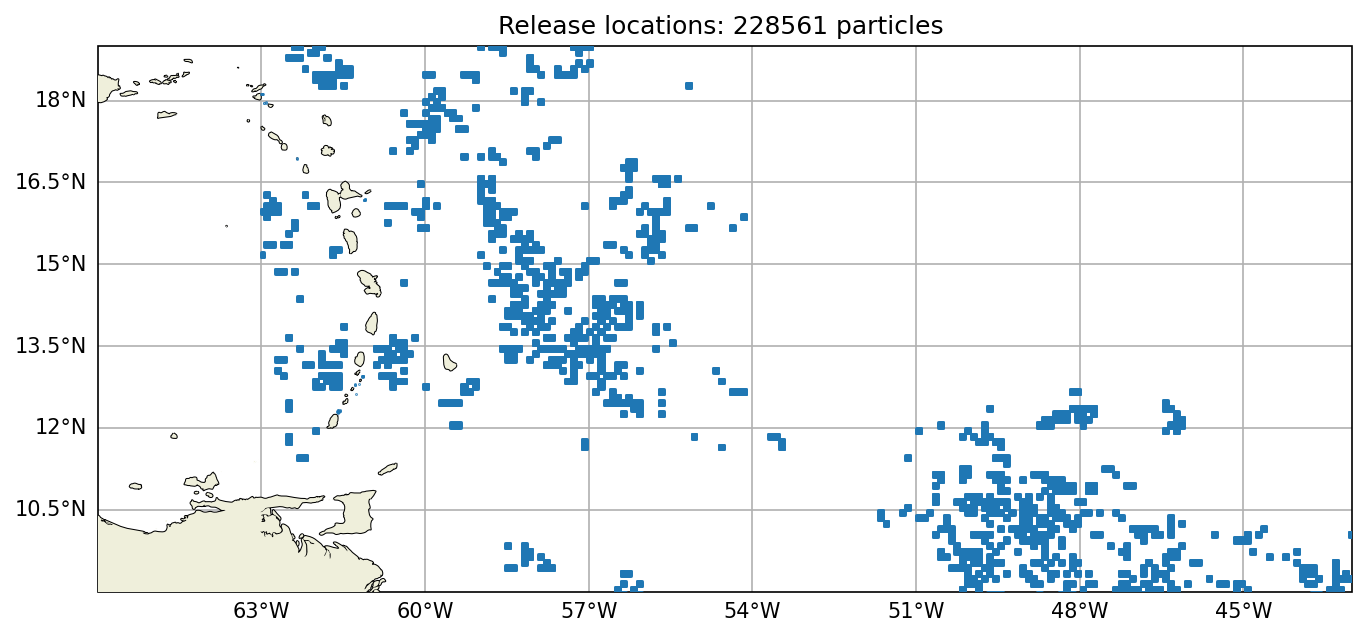

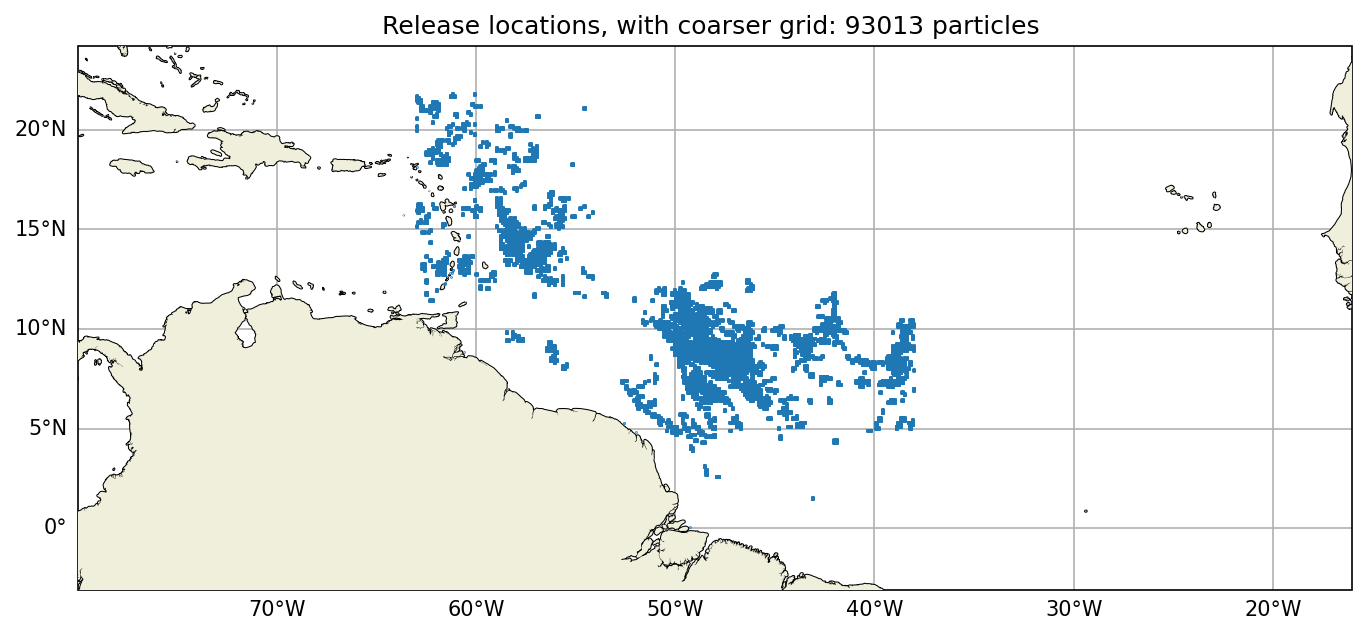

In [7]:
fig = plt.figure(figsize = (9,5), constrained_layout=True, dpi=150)
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'),zorder=3)
ax.add_feature(cartopy.feature.LAND.with_scale('10m'), zorder=4)
ax.gridlines(draw_labels=['left','bottom'], zorder=0)
ax.set_extent([-85,-15,-5,20])
ax.set_extent([-63,-58, 12,17])
ax.set_extent([-80,-16, -3,21])
ax.set_title(f'Release locations, with coarser grid: {np.sum(coarse_mask)} particles ')

ax.scatter(coarse_sarg_lon_grid, coarse_sarg_lat_grid, s = 0.1, label='Release points',zorder=5)
#plt.legend()

plt.show()

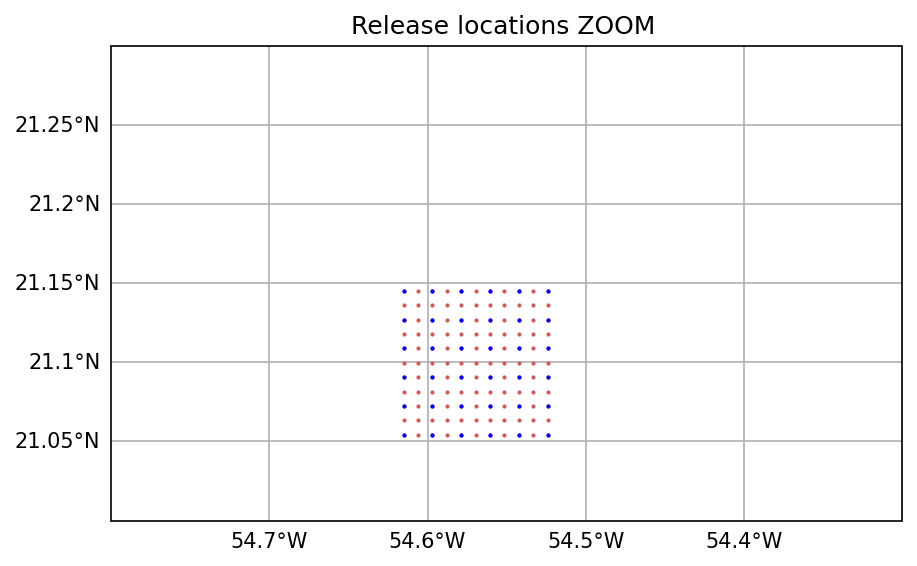

In [33]:
fig = plt.figure(figsize = (6,5), constrained_layout=True, dpi=150)
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'),zorder=3)
ax.add_feature(cartopy.feature.LAND.with_scale('10m'), zorder=4)
ax.gridlines(draw_labels=['left','bottom'], zorder=0)
# ax.set_extent([-85,-15,-5,20])
# ax.set_extent([-63,-58, 12,17])
# ax.set_extent([-80,-16, -3,21])
ax.set_extent([-54.8,-54.3, 21,21.3])
ax.set_title(f'Release locations ZOOM ')
ax.scatter(sarg_lon_grid, sarg_lat_grid, s=1, c= 'indianred',zorder=5)
ax.scatter(coarse_sarg_lon_grid, coarse_sarg_lat_grid, s = 1, c='b', label='Release points',zorder=6)
#plt.legend()

plt.show()

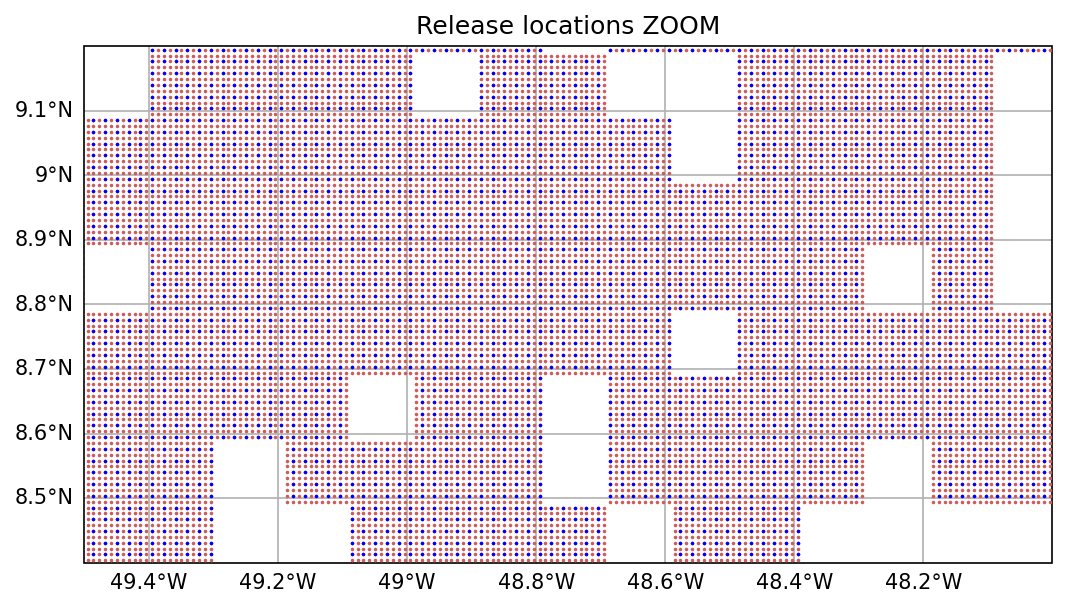

In [39]:
fig = plt.figure(figsize = (7,5), constrained_layout=True, dpi=150)
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'),zorder=3)
ax.add_feature(cartopy.feature.LAND.with_scale('10m'), zorder=4)
ax.gridlines(draw_labels=['left','bottom'], zorder=0)
# ax.set_extent([-85,-15,-5,20])
# ax.set_extent([-63,-58, 12,17])
# ax.set_extent([-80,-16, -3,21])
ax.set_extent([-48,-49.5, 8.4,9.2])
ax.set_title(f'Release locations ZOOM')
ax.scatter(sarg_lon_grid, sarg_lat_grid, s=0.5, c= 'indianred',zorder=5)
ax.scatter(coarse_sarg_lon_grid, coarse_sarg_lat_grid, s = 0.5, c='b', label='Release points',zorder=6)
#plt.legend()

plt.show()

In [11]:
def sarg_grid_from_sat(image_name, north, south, east, west, coarse=False ):

    from PIL import Image

    #Loading the image
    img = Image.open(image_name).convert("RGB")
    img_array = np.array(img)

    #Computing brightness by approximating average or weighted sum of RGB
    brightness = img_array.mean(axis=2)

    #Creating a land mask based on the brown color of landmass
    r, g, b = img_array[:,:,0], img_array[:,:,1], img_array[:,:,2]
    #land_mask = (r > 80) & (g > 40) & (g < 120) & (b < 80)
    #Brown tends to be dark, reddish, and not too saturated
    land_mask = (
        (r > 60) & (r < 160) &          # moderate red
        (g > 30) & (g < 110) &          # moderate green
        (b < 70) &                      # low blue
        (brightness < 120) &            # exclude bright oranges
        ((r - g) > 15) &                # red clearly higher than green
        ((r - b) > 40)                  # red much higher than blue
        )
    #Expanding land mask with binary_dilation method by ~20 pixels (~ km at 1 km resolution)
    from scipy.ndimage import binary_dilation
    expanded_land_mask = binary_dilation(land_mask, iterations=20)

    #Setting threshold to get binary mask - threshold can be adjusted depending on image
    threshold = 60
    binary_mask = (brightness > threshold).astype(int)

    #Applying the expaned land mask on binary mask
    binary_mask[expanded_land_mask] = 0

    #Creating coordinate grids based on bounding boxes
    height, width = binary_mask.shape

    lats = np.linspace(north, south, height)
    lons = np.linspace(west, east, width)

    #Creating 2D coordinate grids
    lon_grid, lat_grid = np.meshgrid(lons, lats)

    #Downsample with stride 2 if you want to select less particles
    stride = 2 if coarse else 1
    mask = binary_mask[::stride, ::stride]
    lat = lat_grid[::stride, ::stride]
    lon = lon_grid[::stride, ::stride]

    amount = int(mask.sum())

    # Create 2D grids of Sargassum release locations
    sarg_lon_grid = xr.DataArray(lon).where(mask == 1)
    sarg_lat_grid = xr.DataArray(lat).where(mask == 1)

    print('Shape of grid:', np.shape(sarg_lon_grid))

    #To prepare the grids as ParticleSet input, NaNs are removed and and arrays are ravelled (flattened)
    no_nan_mask = (~np.isnan(sarg_lon_grid)) & (~np.isnan(sarg_lat_grid)) 
    sarg_lon_grid = sarg_lon_grid.values[no_nan_mask].ravel()
    sarg_lat_grid = sarg_lat_grid.values[no_nan_mask].ravel()
    print('Reshaped grid as particle set:', np.shape(sarg_lon_grid))

    return sarg_lon_grid, sarg_lat_grid, amount

In [6]:
image_name_line_C = "/nethome/6903894/testing/Input_data_test/C20241772024183.1KM.C_ATLANTIC.7DAY.L3D.FA_UNET_DENSITY.png"

image_name_line_CE = "/nethome/6903894/testing/Input_data_test/C20241772024183.1KM.CE_ATLANTIC.7DAY.L3D.FA_UNET_DENSITY.png"

coords_C = 22.0, 0.0, -38.0, -63.0

coords_CE = 22.0, 0.0, -11.5, -38.0

sarg_lon_grid, sarg_lat_grid, amount = sarg_grid_from_sat(image_name_line_C, 22.0, 0.0, -38.0, -63.0, coarse=True )
sarg_depth_grid = np.zeros_like(sarg_lon_grid)
print(type(sarg_lat_grid))
print(np.shape(sarg_lon_grid), np.shape(sarg_lat_grid))
#print(sarg_lon_grid[:,0])
print(amount)
print('')




NameError: name 'sarg_grid_from_sat' is not defined

In [16]:
sarg_lon_grid_W, sarg_lat_grid_W, amount_W = sarg_grid_from_sat(image_name_line_C, 22.0, 0.0, -38.0, -63.0, coarse=True)

Shape of grid: (1210, 1375)
Reshaped grid as particle set: (92988,)


In [17]:
sarg_lon_grid_CE, sarg_lat_grid_CE, amount_CE = sarg_grid_from_sat(image_name_line_CE, 22.0, 0.0, -11.5, -38.0, coarse=True)

sarg_depth_grid = np.zeros_like(sarg_lon_grid_CE)

print('')
print(np.shape(sarg_depth_grid))
amount = amount_CE + amount_W
print(amount_W)
print(type(amount))

amount = int(amount)
print(type(sarg_lon_grid_CE))

sarg_LON = np.append(sarg_lon_grid_W, sarg_lon_grid_CE, axis=0)
sarg_LAT = np.append(sarg_lat_grid_W, sarg_lat_grid_CE, axis=0)

print(np.shape(sarg_LON))

print(amount_W + amount_CE)

Shape of grid: (1210, 1458)
Reshaped grid as particle set: (10626,)

(10626,)
92988
<class 'int'>
<class 'numpy.ndarray'>
(103614,)
103614


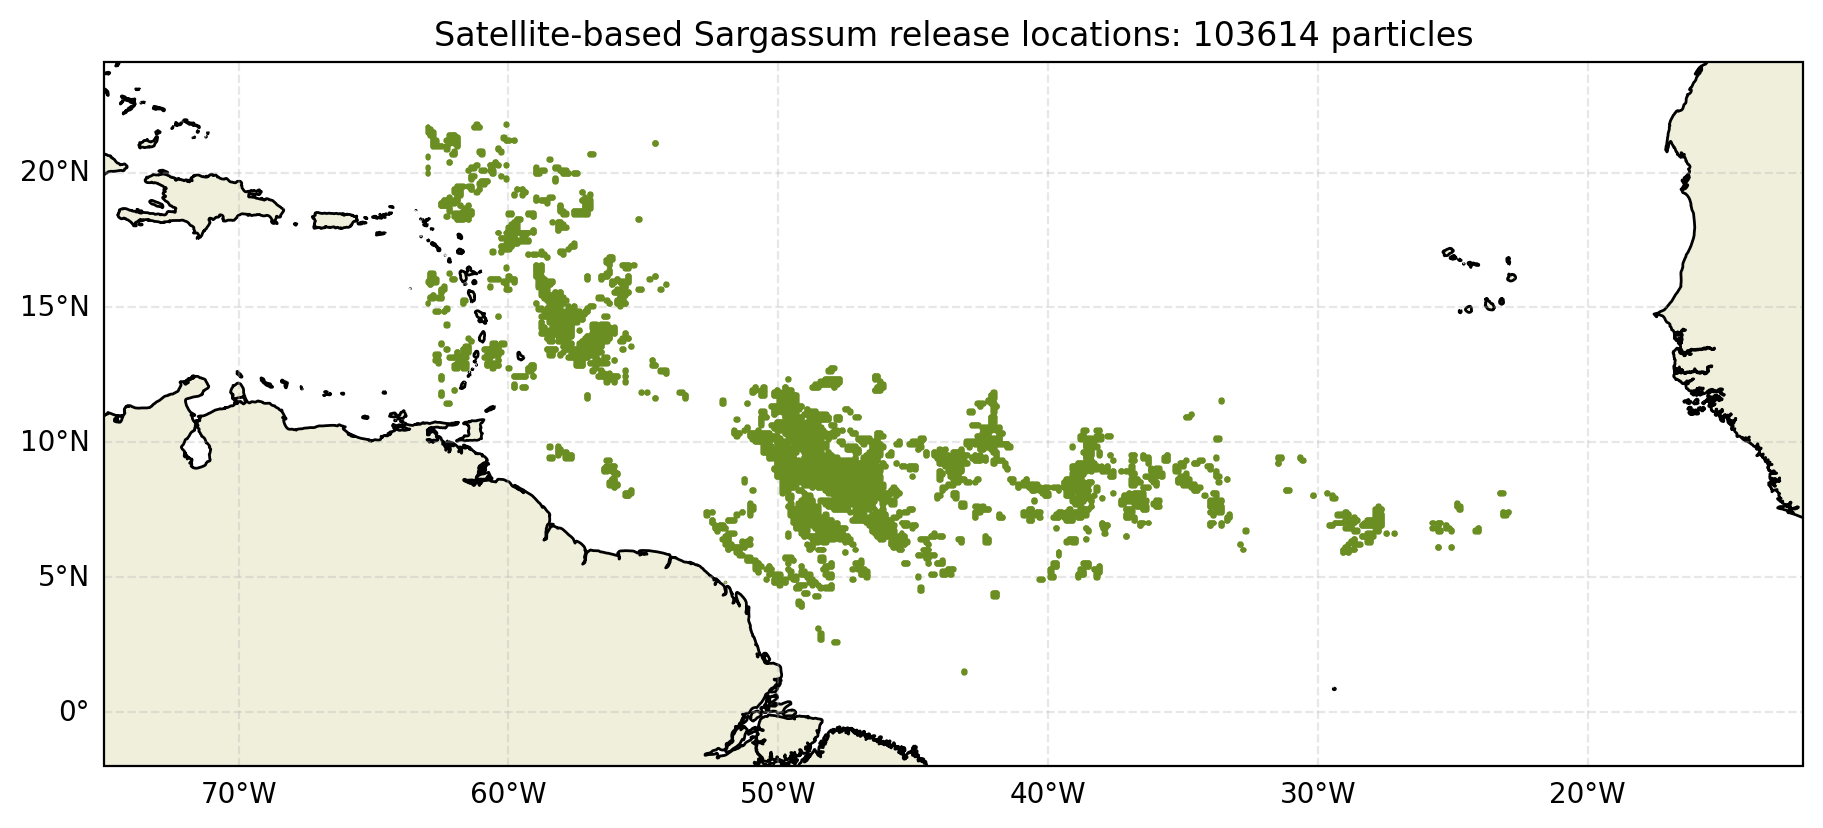

In [20]:
fig = plt.figure(figsize = (9,4), constrained_layout=True, dpi=200)
ax = plt.axes(projection=ccrs.PlateCarree(),zorder=4)
ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'),zorder=2)
ax.add_feature(cartopy.feature.LAND.with_scale('10m'), zorder=1)
ax.gridlines(draw_labels=['left','bottom'], zorder=0, alpha=0.3, linestyle='--')
ax.scatter(sarg_LON, sarg_LAT, s = 0.1, color='olivedrab', zorder=5)
ax.set_extent([-75,-12, -2,21])
ax.set_title(f'Satellite-based Sargassum release locations: {amount_W+amount_CE} particles')
plt.show()

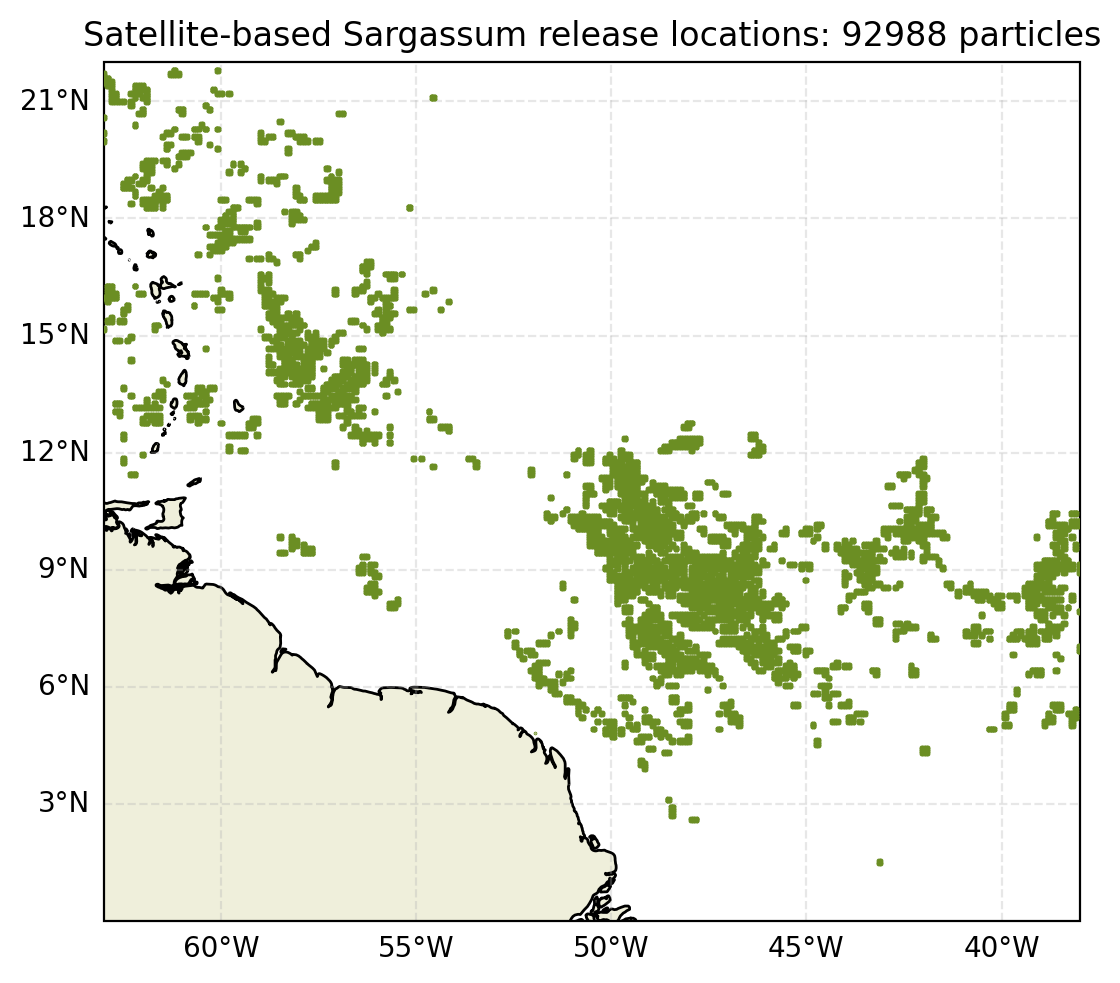

In [23]:
fig = plt.figure( constrained_layout=True, dpi=200)
ax = plt.axes(projection=ccrs.PlateCarree(),zorder=4)
ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'),zorder=2)
ax.add_feature(cartopy.feature.LAND.with_scale('10m'), zorder=1)
ax.gridlines(draw_labels=['left','bottom'], zorder=0, alpha=0.3, linestyle='--')
ax.scatter(sarg_lon_grid_W, sarg_lat_grid_W, s = 0.1, color='olivedrab', zorder=5)
#ax.set_extent([-75,-12, -2,21])22.0, 0.0, -38.0, -63.0
ax.set_extent([-63,-38,0,22])
ax.set_title(f'Satellite-based Sargassum release locations: {amount_W} particles')
plt.show()

In [ ]:
def red_area_from_sat(image_name, north, south, east, west, coarse=False):

    #Loading the image as an RGB array
    from PIL import Image
    img = Image.open(image_name).convert("RGB")
    img_array = np.array(img)

    #Creating a mask only selects red regions of image
    r, g, b = img_array[:,:,0], img_array[:,:,1], img_array[:,:,2]

    red_mask = (
        (r > 150) &                 # strong red channel
        (g < 80)  &                 # green must be low
        (b < 80)  &                 # blue must be low
        ((r - g) > 70) &            # red clearly dominates over green
        ((r - b) > 70)              # red clearly dominates over blue
    )

    #Creating coordinate grids based on bounding boxes
    height, width = red_mask.shape
    lats = np.linspace(north, south, height)
    lons = np.linspace(west, east, width)

    #Creating 2D coordinate grids
    lon_grid, lat_grid = np.meshgrid(lons, lats)

    #Downsample with stride 2 if you want to select less particles
    stride = 2 if coarse else 1
    mask = red_mask[::stride, ::stride]
    lat = lat_grid[::stride, ::stride]
    lon = lon_grid[::stride, ::stride]

    amount = int(mask.sum())

    #Creating 2D grids of Sargassum release locations
    sarg_lon_grid = xr.DataArray(lon).where(mask == 1)
    sarg_lat_grid = xr.DataArray(lat).where(mask == 1)
    print('Shape of grid:', np.shape(sarg_lon_grid))

    #To prepare the grids as ParticleSet input, NaNs are removed and and arrays are ravelled (flattened)
    no_nan_mask = (~np.isnan(sarg_lon_grid)) & (~np.isnan(sarg_lat_grid)) 
    sarg_lon_grid = sarg_lon_grid.values[no_nan_mask].ravel()
    sarg_lat_grid = sarg_lat_grid.values[no_nan_mask].ravel()
    print('Reshaped grid as particle set:', np.shape(sarg_lon_grid))

    return sarg_lon_grid, sarg_lat_grid, amount

Shape of grid: (1210, 1375)
Reshaped grid as particle set: (24176,)


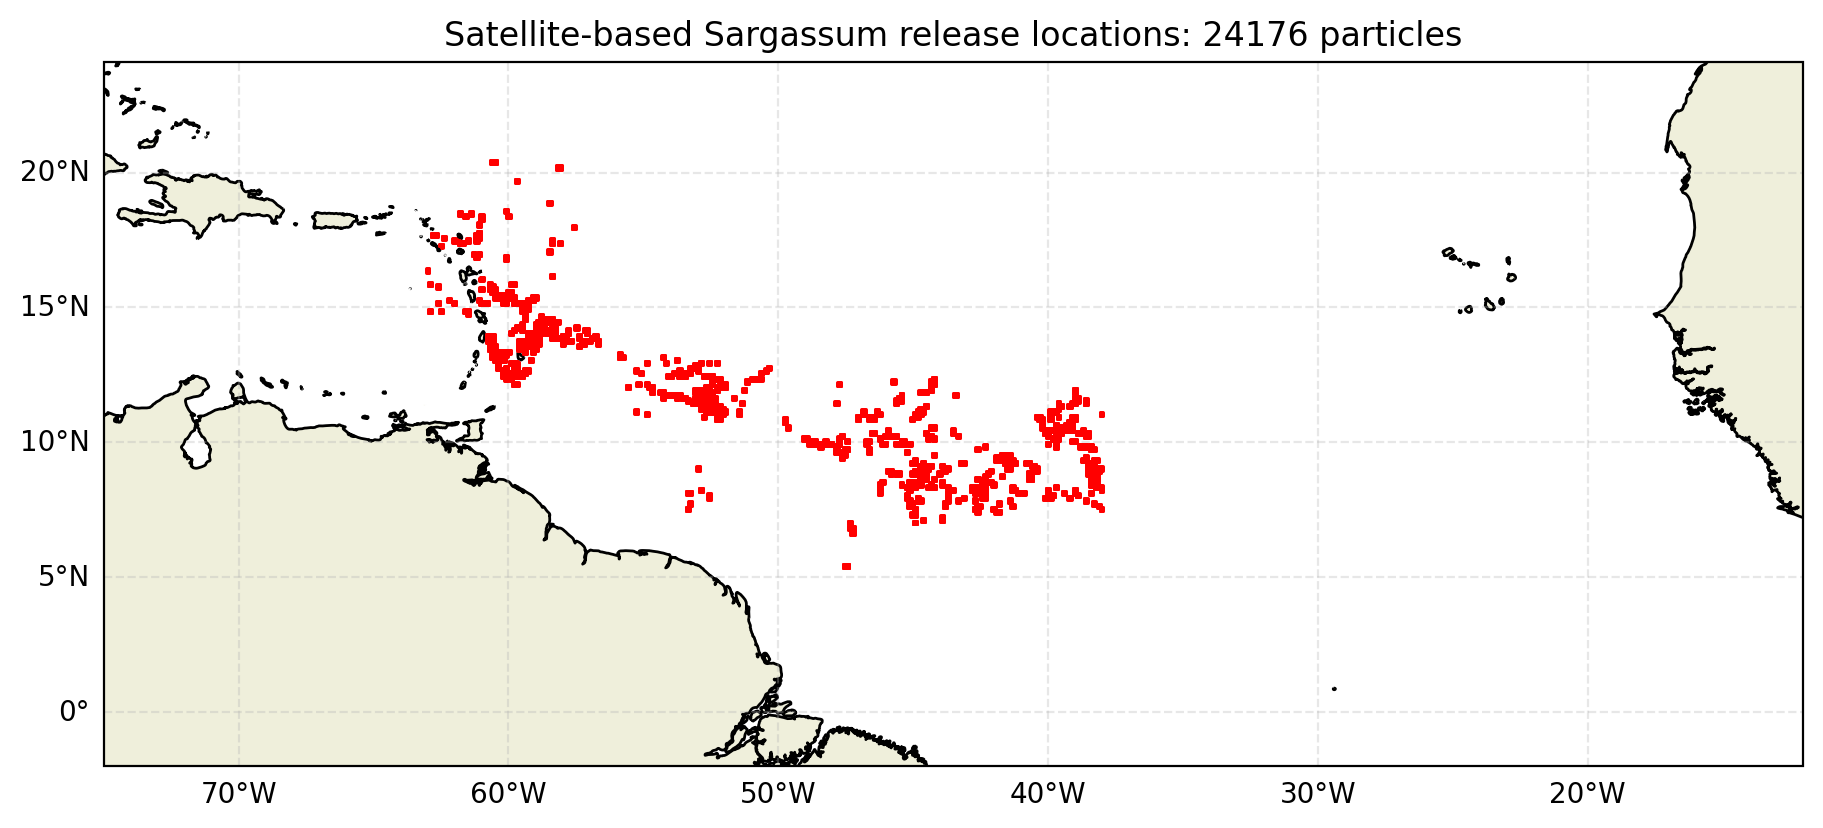

In [12]:
image_name_line = '/nethome/6903894/testing/Input_data_test/C20242082024214.1KM.C_ATLANTIC.7DAY.L3D.FA_UNET_DENSITY.png'

red_lon_grid_W, red_lat_grid_W, amount_red = red_area_from_sat(image_name_line, 22.0, 0.0, -38.0, -63.0, coarse=True)

fig = plt.figure(figsize = (9,4), constrained_layout=True, dpi=200)
ax = plt.axes(projection=ccrs.PlateCarree(),zorder=4)
ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'),zorder=2)
ax.add_feature(cartopy.feature.LAND.with_scale('10m'), zorder=1)
ax.gridlines(draw_labels=['left','bottom'], zorder=0, alpha=0.3, linestyle='--')
ax.scatter(red_lon_grid_W, red_lat_grid_W, s = 1, marker = 's', color='red', zorder=5)
ax.set_extent([-75,-12, -2,21])
ax.set_title(f'Satellite-based Sargassum release locations: {amount_red} particles')
plt.show()